In [64]:
import jax
from jax import lax
from jax import numpy as jnp
import numpy as np
import einops
import equinox as eqx
import optax

import matplotlib.pyplot as plt

from jaxtyping import Array

Text(0.5, 1.0, '1 sequence encoding')

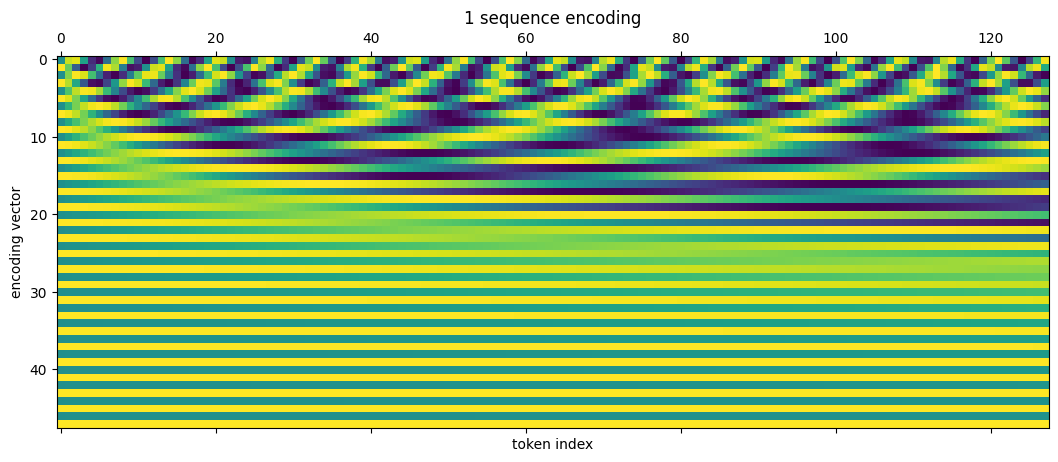

In [65]:
def get_pe_1d(idx, dim: int, seq_len: int = 5000):
    """
    Args:
        x: (S, D) sequence of tokens
        dim (int): _description_
        seq_len (int, optional): _description_. Defaults to 5000.
    """
    pe = np.zeros((seq_len, dim))
    position = np.arange(0, seq_len, dtype=np.float32)[:, None]
    div_term = np.exp(np.arange(0, dim, 2) * (-np.log(10000.0) / dim))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)
    embed = pe[idx]
    return embed

x = jnp.zeros((128, 48))
enc = get_pe_1d(jnp.arange(x.shape[0]), 48)
plt.matshow(enc.T)
plt.xlabel("token index")
plt.ylabel("encoding vector")
plt.title("1 sequence encoding")

<class 'jaxlib._jax.ArrayImpl'>


Text(0.5, 1.0, '2d grid sequence encoding')

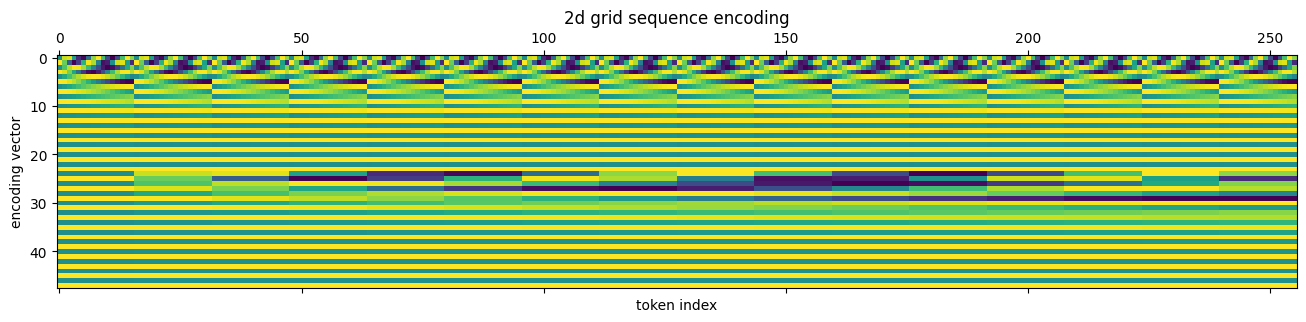

In [66]:
def get_pe_2d(x, dim, grid_size, seq_len=5000):
    grid_h = jnp.arange(grid_size, dtype=float)
    grid_w = jnp.arange(grid_size, dtype=float)
    grid = jnp.meshgrid(grid_w, grid_h)  # here w goes first
    grid = jnp.stack(grid, axis=0).astype(int)
    print(type(grid))

    return get_pe_2d_from_grid(x, dim, grid, seq_len=seq_len)

def get_pe_2d_from_grid(x, dim, grid, seq_len=5000):
    assert dim % 2 == 0

    encx = get_pe_1d(grid[0].flatten(), dim // 2, seq_len=seq_len)
    ency = get_pe_1d(grid[1].flatten(), dim // 2, seq_len=seq_len)
    enc = jnp.concatenate([encx, ency], axis=-1) # concatenate the halved dims

    return enc


enc = get_pe_2d(x, 48, 16)
plt.matshow(enc.T)
plt.xlabel("token index")
plt.ylabel("encoding vector")
plt.title("2d grid sequence encoding")

## Class implementation

In [ ]:

class PositionalEncoding(eqx.Module):
    """Sinusoidal positional encoding"""
    pe: Array = eqx.field(static=True)
    dim: int  = eqx.field(static=True)
    
    def __init__(self, dim: int, seq_len: int = 5000):
        self.dim = dim
        pe = np.zeros((seq_len, dim))
        position = np.arange(0, seq_len, dtype=np.float32)[:, None]
        div_term = np.exp(np.arange(0, dim, 2) * (-np.log(10000.0) / dim))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)
        self.pe = jnp.array(pe)

    def pe_from_idx(self, idx):
        return self.pe[idx]
    
    def __call__(self, x):
        # x: (S, D)
        seq_len = x.shape[0]
        return x + self.pe[:seq_len]
    

class PositionalEncoding2D(PositionalEncoding):
    grid: Array
    dim: int
    
    def __init__(self, grid_size: int, dim: int, seq_len: int = 5000):
        super().__init__(self.dim // 2, seq_len=seq_len)

        self.dim = dim
        self.grid = self._get_pe_grid(grid_size)
        
    def _get_pe_grid(self, grid_size):
        grid_h = jnp.arange(grid_size, dtype=float)
        grid_w = jnp.arange(grid_size, dtype=float)
        grid = jnp.meshgrid(grid_w, grid_h)
        grid = jnp.stack(grid, axis=0).astype(int)
        return grid
    
    def __call__(self, x):
        """
        Assume x is (grid_size * grid_size, D) tokens
        """
        assert x.shape[0] == self.grid.shape[1]**2

        encx = self.pe_from_idx(self.grid[0].flatten())
        ency = self.pe_from_idx(self.grid[1].flatten())
        enc = jnp.concatenate([encx, ency], axis=-1) # concatenate the halved dims

        return x + enc

/var/folders/82/kqk386yx56s3vbqsdcrdr_wc0000gn/T/ipykernel_39100/401683939.py:1: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  grid_pe = PositionalEncoding2D(grid_size=16, dim=48)


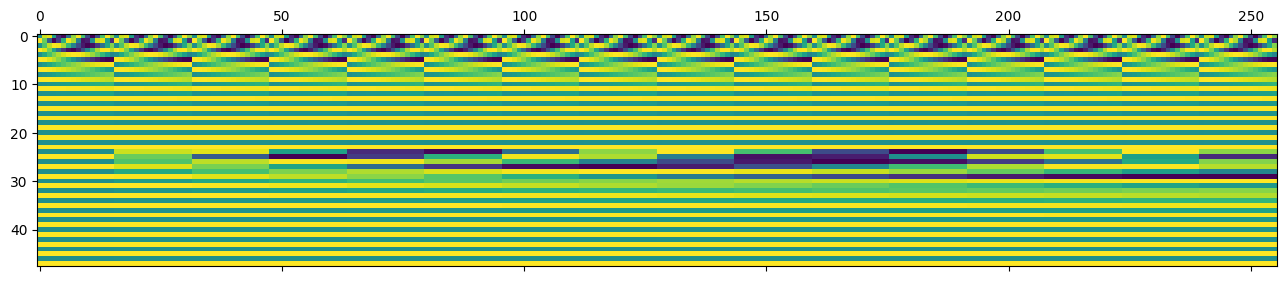

In [68]:
grid_pe = PositionalEncoding2D(grid_size=16, dim=48)
enc_2d = grid_pe(jnp.zeros((256, 48)))
plt.matshow(enc_2d.T)
